In [ ]:
from pathlib import Path
import nibabel as nib
import numpy as np

ct_pwd = Path("/home/rahuldeb5/research/datasets/pants/train/masks/PanTS_00000003/")

files = [f for f in sorted(ct_pwd.glob("*.nii.gz"))]
# print(files[21])

img = nib.load(files[0])

affine = img.affine
spacing = np.abs(np.diag(affine)[:3])
# print(spacing[0])

# volume = img.get_fdata()

# print(volume)
# print(volume.shape)
# print(volume.dtype)

# print(volume.min())
# print(volume.max())

0.8183590173721313


In [ ]:
import matplotlib.pyplot as plt
data = img.get_fdata()
plt.imshow(data[:, :, 20], cmap='gray')  # middle axial slice


In [ ]:
from pathlib import Path
import nibabel as nib
from scipy import ndimage


ct_pwd = Path("/home/rahuldeb5/research/datasets/pants/train/masks/")

subdirectories = [p for p in ct_pwd.iterdir() if p.is_dir()]

zero = 0
one = 0

for dir in subdirectories:
    files = [f for f in sorted(dir.glob("*.nii.gz"))]
    
    img = nib.load(files[0])
    volume = img.get_fdata()

    tumor_mask = (volume == 1)
    labeled, n = ndimage.label(tumor_mask)

    print(n)

    if(n == 0):
        zero += 1
    elif(n == 1):
        one += 1

print("zero: " + str(zero))
print("one: " + str(one))

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
0
1
1
0
1
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
1
1
2
1
1
1
0
1
1
1
1
1
1
1
1
1
1
1
1
2
1
1
1
1
1
1
1
1
1


KeyboardInterrupt: 

In [48]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import nibabel as nib
from scipy import ndimage
from collections import Counter
import numpy as np
import csv

min_voxels = 10

def process_mask_dir(dir_path):
    try:
        files = sorted(dir_path.glob("*.nii.gz"))
        if not files:
            return None

        img = nib.load(files[0])
        affine = img.affine
        spacing = np.abs(np.diag(affine)[:3])
        volume = img.dataobj[...]

        tumor_mask = volume == 1
        labeled, n = ndimage.label(tumor_mask)

        results = []

        for i in range(1, n + 1):
            coords = np.argwhere(labeled == i)

            if len(coords) < min_voxels:
                continue

            extents_mm = (coords.max(axis=0) - coords.min(axis=0) + 1) * np.array(spacing)
            volume_mm3 = len(coords) * np.prod(spacing)
            equiv_diam_mm = 2 * (3 * volume_mm3 / (4 * np.pi)) ** (1 / 3)

            results.append({
                "min_axis_extent_mm": extents_mm.min(),
                "equivalent_diameter_mm": equiv_diam_mm,
            })

        return {
            "id": dir_path.name,
            "num_components": n,
            "components": results
        }

    except Exception as e:
        print(f"Error processing {dir_path.name}: {e}")
        return None


ct_pwd = Path("/home/rahuldeb5/research/datasets/pants/train/masks/")
test_pwd = Path("/home/rahuldeb5/research/datasets/pants/test/masks/")

subdirectories = [p for p in ct_pwd.iterdir() if p.is_dir()]
test_sub = [p for p in test_pwd.iterdir() if p.is_dir()]
subdirectories += test_sub

with ThreadPoolExecutor(max_workers=16) as executor:
    processed_outputs = list(executor.map(process_mask_dir, subdirectories))

valid_outputs = [res for res in processed_outputs if res is not None]

counts = Counter(res["num_components"] for res in valid_outputs)

for tumor_count, frequency in sorted(counts.items()):
    print(f"{tumor_count}: {frequency}")

csv_path = Path("./mask_metadata.csv")

with open(csv_path, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "num_components", "component_index", "min_axis_extent_mm", "equivalent_diameter_mm"])
    
    for item in valid_outputs:
        patient_id = item["id"]
        num_comp = item["num_components"]
        
        if not item["components"]:
            writer.writerow([patient_id, num_comp, None, None, None])
        else:
            for idx, comp in enumerate(item["components"], start=1):
                writer.writerow([
                    patient_id,
                    num_comp,
                    idx,
                    comp["min_axis_extent_mm"],
                    comp["equivalent_diameter_mm"]
                ])

0: 68
1: 1299
2: 49
3: 9
4: 5
5: 2
6: 3
8: 1


In [49]:
import pandas as pd

# 1. Load the CSV files
df_original = pd.read_csv("data/pants - PanTS_metadata (1).csv")
df_masks = pd.read_csv("./mask_metadata.csv")

# 2. Clean column names (strip whitespace) to prevent key errors
df_original.columns = df_original.columns.str.strip()
df_masks.columns = df_masks.columns.str.strip()

# 3. Merge metadata on the ID column
# Left join keeps all mask entries matched with their patient tumor status
df_merged = pd.merge(
    df_masks,
    df_original[["PanTS ID", "tumor?"]],
    left_on="id",
    right_on="PanTS ID",
    how="inner"
)

# 4. Separate cases with tumors (tumor? == 1) and without tumors (tumor? == 0)
df_with_tumors = df_merged[df_merged["tumor?"] == 1]
df_without_tumors = df_merged[df_merged["tumor?"] == 0]

# Metrics to evaluate
metrics = ["num_components", "component_index", "min_axis_extent_mm", "equivalent_diameter_mm"]

# 5. Print distribution summaries
print("=" * 60)
print("DISTRIBUTION FOR SCANS WITH TUMORS (tumor? == 1)")
print("=" * 60)
print(df_with_tumors[metrics].describe().T[["count", "mean", "std", "min", "50%", "max"]])

print("\n" + "=" * 60)
print("DISTRIBUTION FOR SCANS WITHOUT TUMORS (tumor? == 0)")
print("=" * 60)
print(df_without_tumors[metrics].describe().T[["count", "mean", "std", "min", "50%", "max"]])

DISTRIBUTION FOR SCANS WITH TUMORS (tumor? == 1)
                         count       mean       std  min        50%        max
num_components          1104.0   1.096014  0.674508  0.0   1.000000   8.000000
component_index         1065.0   1.031925  0.214412  1.0   1.000000   4.000000
min_axis_extent_mm      1065.0  21.702518  6.925971  0.0  21.978505  41.015605
equivalent_diameter_mm  1065.0  19.962285  4.761958  0.0  20.545516  37.308666

DISTRIBUTION FOR SCANS WITHOUT TUMORS (tumor? == 0)
                        count       mean       std  min        50%        max
num_components          369.0   1.048780  0.554434  0.0   1.000000   5.000000
component_index         338.0   1.029586  0.169693  1.0   1.000000   2.000000
min_axis_extent_mm      338.0  20.719869  7.870705  0.0  22.079099  39.013672
equivalent_diameter_mm  338.0  19.007500  6.185717  0.0  20.028102  36.144956


/tmp/ipykernel_23723/2791560393.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_23723/2791560393.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_23723/2791560393.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


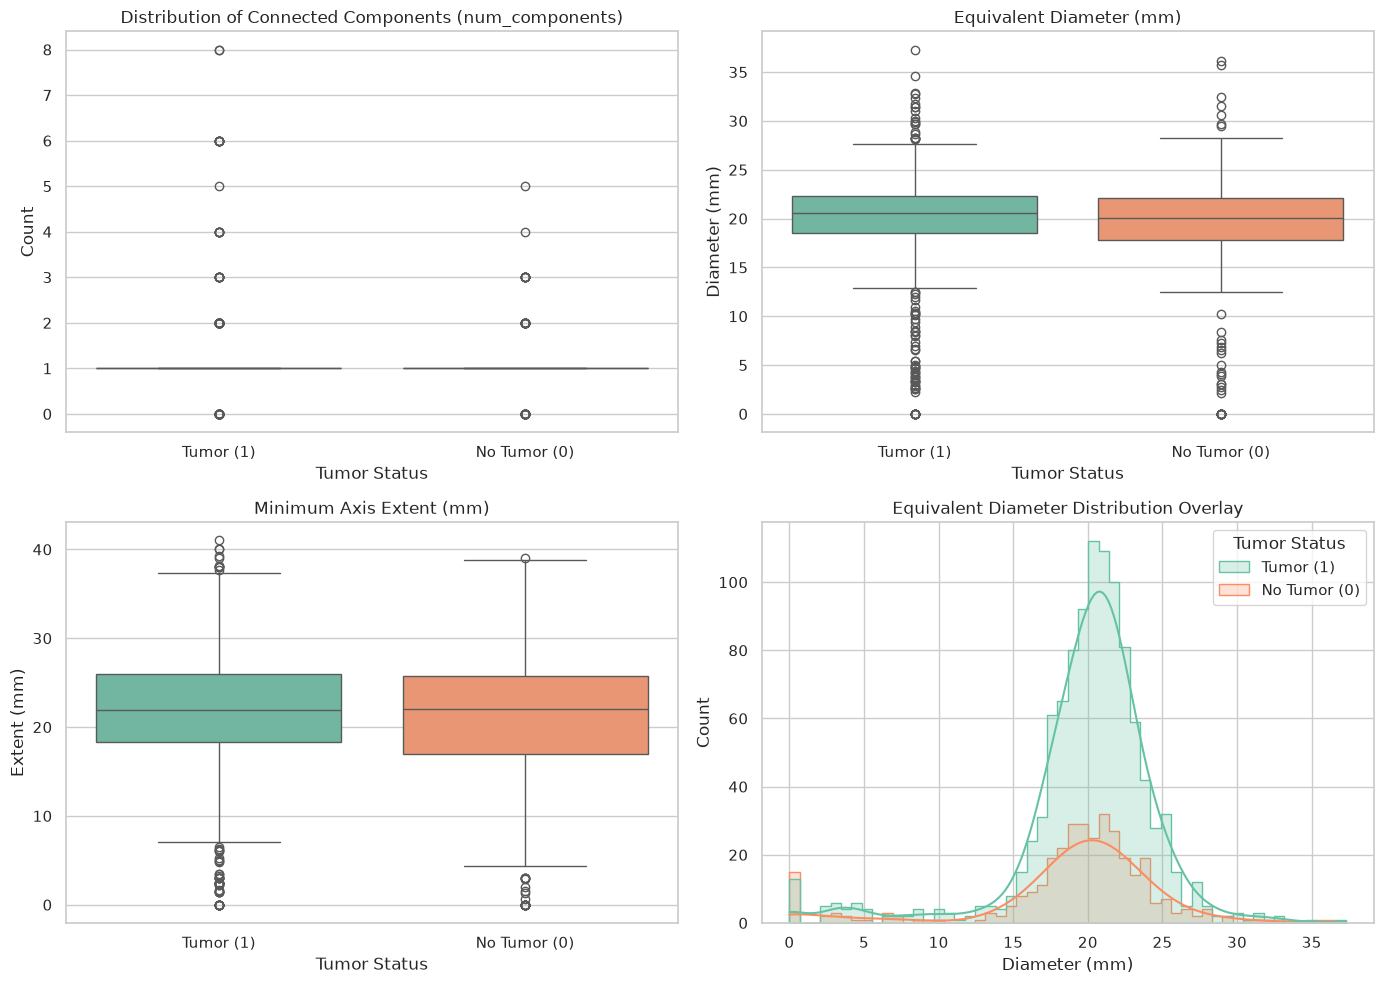

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and merge the data
df_original = pd.read_csv("data/pants - PanTS_metadata (1).csv")
df_masks = pd.read_csv("./mask_metadata.csv")

df_original.columns = df_original.columns.str.strip()
df_masks.columns = df_masks.columns.str.strip()

df_merged = pd.merge(
    df_masks,
    df_original[["PanTS ID", "tumor?"]],
    left_on="id",
    right_on="PanTS ID",
    how="inner"
)

# Create a human-readable label for plotting
df_merged["Tumor Status"] = df_merged["tumor?"].map({1: "Tumor (1)", 0: "No Tumor (0)"})

# Set plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2. Boxplot: Number of Components per Scan
sns.boxplot(
    data=df_merged,
    x="Tumor Status",
    y="num_components",
    ax=axes[0, 0],
    palette="Set2"
)
axes[0, 0].set_title("Distribution of Connected Components (num_components)")
axes[0, 0].set_ylabel("Count")

# 3. Boxplot: Equivalent Diameter (mm)
sns.boxplot(
    data=df_merged.dropna(subset=["equivalent_diameter_mm"]),
    x="Tumor Status",
    y="equivalent_diameter_mm",
    ax=axes[0, 1],
    palette="Set2"
)
axes[0, 1].set_title("Equivalent Diameter (mm)")
axes[0, 1].set_ylabel("Diameter (mm)")

# 4. Boxplot: Minimum Axis Extent (mm)
sns.boxplot(
    data=df_merged.dropna(subset=["min_axis_extent_mm"]),
    x="Tumor Status",
    y="min_axis_extent_mm",
    ax=axes[1, 0],
    palette="Set2"
)
axes[1, 0].set_title("Minimum Axis Extent (mm)")
axes[1, 0].set_ylabel("Extent (mm)")

# 5. Histogram: Overlay of Equivalent Diameter
sns.histplot(
    data=df_merged.dropna(subset=["equivalent_diameter_mm"]),
    x="equivalent_diameter_mm",
    hue="Tumor Status",
    kde=True,
    element="step",
    ax=axes[1, 1],
    palette="Set2"
)
axes[1, 1].set_title("Equivalent Diameter Distribution Overlay")
axes[1, 1].set_xlabel("Diameter (mm)")

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

# 1. Load the CSV files
df_original = pd.read_csv("data/pants - PanTS_metadata (1).csv")
df_masks = pd.read_csv("./mask_metadata.csv")

# Clean column names
df_original.columns = df_original.columns.str.strip()
df_masks.columns = df_masks.columns.str.strip()

# 2. Merge metadata on ID
df_merged = pd.merge(
    df_masks,
    df_original[["PanTS ID", "tumor?"]],
    left_on="id",
    right_on="PanTS ID",
    how="inner"
)

# Function to run extent analysis on a given subset
def print_extent_analysis(series, group_label):
    series = series.dropna()
    print("=" * 60)
    print(f"MIN AXIS EXTENT ANALYSIS: {group_label}")
    print("=" * 60)
    print(f"Total valid components measured: {len(series)}")
    print("\nQuantiles:")
    print(series.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75]))
    print("\nThreshold Counts:")
    print("Below 20mm (R-Super threshold):", (series < 20).sum())
    print("Below 15mm:                    ", (series < 15).sum())
    print("Below 10mm:                    ", (series < 10).sum())
    print("\n")

# 3. Extract min extent series for tumor and non-tumor cases
tumor_extents = df_merged[df_merged["tumor?"] == 1]["min_axis_extent_mm"]
non_tumor_extents = df_merged[df_merged["tumor?"] == 0]["min_axis_extent_mm"]

# 4. Run analysis
print_extent_analysis(tumor_extents, "CT Scans WITH Tumors (tumor? == 1)")
print_extent_analysis(non_tumor_extents, "CT Scans WITHOUT Tumors (tumor? == 0)")

MIN AXIS EXTENT ANALYSIS: CT Scans WITH Tumors (tumor? == 1)
Total valid components measured: 1065

Quantiles:
0.01     0.000000
0.05     8.982502
0.10    14.182032
0.25    18.328125
0.50    21.978505
0.75    25.976579
Name: min_axis_extent_mm, dtype: float64

Threshold Counts:
Below 20mm (R-Super threshold): 380
Below 15mm:                     127
Below 10mm:                     58


MIN AXIS EXTENT ANALYSIS: CT Scans WITHOUT Tumors (tumor? == 0)
Total valid components measured: 338

Quantiles:
0.01     0.000000
0.05     1.533203
0.10    11.966016
0.25    17.020000
0.50    22.079099
0.75    25.762204
Name: min_axis_extent_mm, dtype: float64

Threshold Counts:
Below 20mm (R-Super threshold): 130
Below 15mm:                     53
Below 10mm:                     30




In [52]:
import pandas as pd
import numpy as np
import ast

# 1. Load the original metadata CSV
df_original = pd.read_csv("data/pants - PanTS_metadata (1).csv")
df_original.columns = df_original.columns.str.strip()

# 2. Parse string tuples like "(0.625, 0.625, 0.8)" into 1D numpy arrays of float
def parse_spacing(spacing_str):
    try:
        # ast.literal_eval converts string "(0.625, 0.625, 0.8)" to tuple (0.625, 0.625, 0.8)
        return np.array(ast.literal_eval(str(spacing_str)), dtype=float)
    except (ValueError, SyntaxError):
        return np.array([np.nan, np.nan, np.nan])

# Apply parsing across the spacing column
spacing_vectors = df_original["spacing"].apply(parse_spacing)

# 3. Create a DataFrame for individual axes (X, Y, Z)
spacing_matrix = np.vstack(spacing_vectors.values)
df_spacing = pd.DataFrame(spacing_matrix, columns=["Spacing_X_mm", "Spacing_Y_mm", "Spacing_Z_mm"])

# 4. Compute and display descriptive statistics for each axis
stats = df_spacing.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T
stats["median"] = df_spacing.median()

# Reorder columns for clarity
columns_order = ["count", "mean", "std", "min", "1%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "99%", "max"]
stats = stats[columns_order]

print("=" * 80)
print("SPACING DISTRIBUTION BY AXIS (in mm)")
print("=" * 80)
print(stats.to_string())

SPACING DISTRIBUTION BY AXIS (in mm)
               count      mean       std       min        1%        5%       10%       25%       50%       75%  90%  95%  99%   max
Spacing_X_mm  9901.0  1.014107  0.700672  0.423177  0.546875  0.636719  0.673828  0.742188  0.808594  0.976562  1.5  1.5  5.0   5.0
Spacing_Y_mm  9901.0  0.891852  0.282958  0.392578  0.583984  0.640625  0.673828  0.738281  0.796875  0.949219  1.5  1.5  1.5   5.0
Spacing_Z_mm  9901.0  1.770137  1.349231  0.363304  0.625000  0.781250  0.800000  0.800000  1.250000  2.500000  5.0  5.0  5.0  10.0


In [ ]:
import pandas as pd
import numpy as np
import ast

# 1. Load original metadata
df_original = pd.read_csv("data/pants - PanTS_metadata (1).csv")
df_original.columns = df_original.columns.str.strip()

# 2. Parse spacing string tuple into array
def parse_spacing(spacing_str):
    try:
        return np.array(ast.literal_eval(str(spacing_str)), dtype=float)
    except (ValueError, SyntaxError):
        return np.array([np.nan, np.nan, np.nan])

spacing_vectors = df_original["spacing"].apply(parse_spacing)
spacing_matrix = np.vstack(spacing_vectors.values)

# Extract Z spacing specifically
df_original["Spacing_Z_mm"] = spacing_matrix[:, 2]

# Ensure ID column names match for merge (adjust 'id' if original uses 'PanTS ID' or similar)
id_col_original = "id" if "id" in df_original.columns else "PanTS ID"

# 3. Load the new measurements file (replace 'new_metadata.csv' with your filename)
df_new = pd.read_csv("mask_metadata.csv")
df_new.columns = df_new.columns.str.strip()

# Standardize IDs to string for clean join
df_original[id_col_original] = df_original[id_col_original].astype(str).str.strip()
df_new["id"] = df_new["id"].astype(str).str.strip()

# 4. Merge native Z-spacing into the new metadata
merged = df_new.merge(
    df_original[[id_col_original, "Spacing_Z_mm"]],
    left_on="id",
    right_on=id_col_original,
    how="inner"
)

# 5. Check Z-axis undersampling: fewer than 3 real voxels along narrowest axis
merged["z_undersampled"] = merged["Spacing_Z_mm"] > (merged["min_axis_extent_mm"] / 3.0)

# 6. Group by tumor size bins and print distribution
bins = [0, 10, 15, 20, 999]
labels = ["< 10 mm", "10-15 mm", "15-20 mm", "> 20 mm"]

merged["size_bin"] = pd.cut(merged["min_axis_extent_mm"], bins=bins, labels=labels)

summary = merged.groupby("size_bin", observed=False).agg(
    total_components=("id", "count"),
    undersampled_count=("z_undersampled", "sum"),
    undersampled_pct=("z_undersampled", lambda x: x.mean() * 100)
).reset_index()

print("=" * 80)
print("Z-AXIS UNDERSAMPLING CHECK BY MINIMUM AXIS EXTENT")
print("=" * 80)
print(summary.to_string(index=False, formatters={"undersampled_pct": "{:.1f}%".format}))
print("-" * 80)
print(f"Total Undersampled Components: {merged['z_undersampled'].sum()} / {len(merged)} ({merged['z_undersampled'].mean() * 100:.1f}%)")

FileNotFoundError: [Errno 2] No such file or directory: 'new_metadata.csv'

In [ ]:
# 7. Tag each case with its split (train/test) and tumor-confirmed status
# Splits live in src/data/PanTS/{train,test}_{pos,neg}.txt (pos = tumor confirmed
# via the "tumor?" field in PanTS_metadata.csv, neg = a sampled subset of unconfirmed cases)
splits_dir = Path("../../src/data/PanTS")

def load_ids(filename):
    return set((splits_dir / filename).read_text().split())

split_ids = {
    ("train", True): load_ids("train_pos.txt"),
    ("train", False): load_ids("train_neg.txt"),
    ("test", True): load_ids("test_pos.txt"),
    ("test", False): load_ids("test_neg.txt"),
}

id_to_split = {}
id_to_tumor_confirmed = {}
for (split_name, tumor_confirmed), ids in split_ids.items():
    for case_id in ids:
        id_to_split[case_id] = split_name
        id_to_tumor_confirmed[case_id] = tumor_confirmed

merged["split"] = merged["id"].map(id_to_split)
merged["tumor_confirmed"] = merged["id"].map(id_to_tumor_confirmed)

# Restrict to cases that are actually part of the official train/test pos+neg lists
merged = merged[merged["split"].notna()].copy()

# 8. Per-split summary (train = train_pos + train_neg, test = test_pos + test_neg),
# broken out by tumor-confirmed status
for split_name in ["train", "test"]:
    split_df = merged[merged["split"] == split_name]
    summary = split_df.groupby(["size_bin", "tumor_confirmed"], observed=False).agg(
        total_components=("id", "count"),
        undersampled_count=("z_undersampled", "sum"),
        undersampled_pct=("z_undersampled", lambda x: x.mean() * 100 if len(x) else np.nan),
    ).reset_index()

    print("=" * 80)
    print(f"{split_name.upper()} SET — Z-AXIS UNDERSAMPLING BY SIZE BIN AND TUMOR-CONFIRMED STATUS")
    print("=" * 80)
    print(summary.to_string(index=False, formatters={"undersampled_pct": "{:.1f}%".format}))
    n_confirmed = split_df["tumor_confirmed"].sum()
    print("-" * 80)
    print(
        f"{split_name}: {len(split_df)} components "
        f"({n_confirmed} tumor-confirmed, {len(split_df) - n_confirmed} not confirmed), "
        f"{split_df['z_undersampled'].sum()} undersampled ({split_df['z_undersampled'].mean() * 100:.1f}%)"
    )
    print()
